# Task -Image Classification Using the CIFAR-10 Dataset
The CIFAR-10 dataset was loaded using the PyTorch `torchvision.datasets` module, which automatically downloads and splits the dataset into training (50,000 images) and test (10,000 images) sets.

## Reference
- Krizhevsky, A. CIFAR-10 Dataset. Available at: [https://www.cs.toronto.edu/~kriz/cifar.html](https://www.cs.toronto.edu/~kriz/cifar.html)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import os

from sklearn.linear_model import LogisticRegression
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from sklearn.preprocessing import StandardScaler

import optuna

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
# train set = used to learn
# test set = used to evaluate on unseen images

# define transform (convert to tensor)
transform = transforms.ToTensor()

# load training set
# this contains 50,000 images used for training
train_data = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,   # downloads automatically if not already present
    transform=transform
)

# load test set
# this contains 10,000 images used for testing
test_data = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

c:\Users\adubu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Testing Data Set
To visualise data set being used

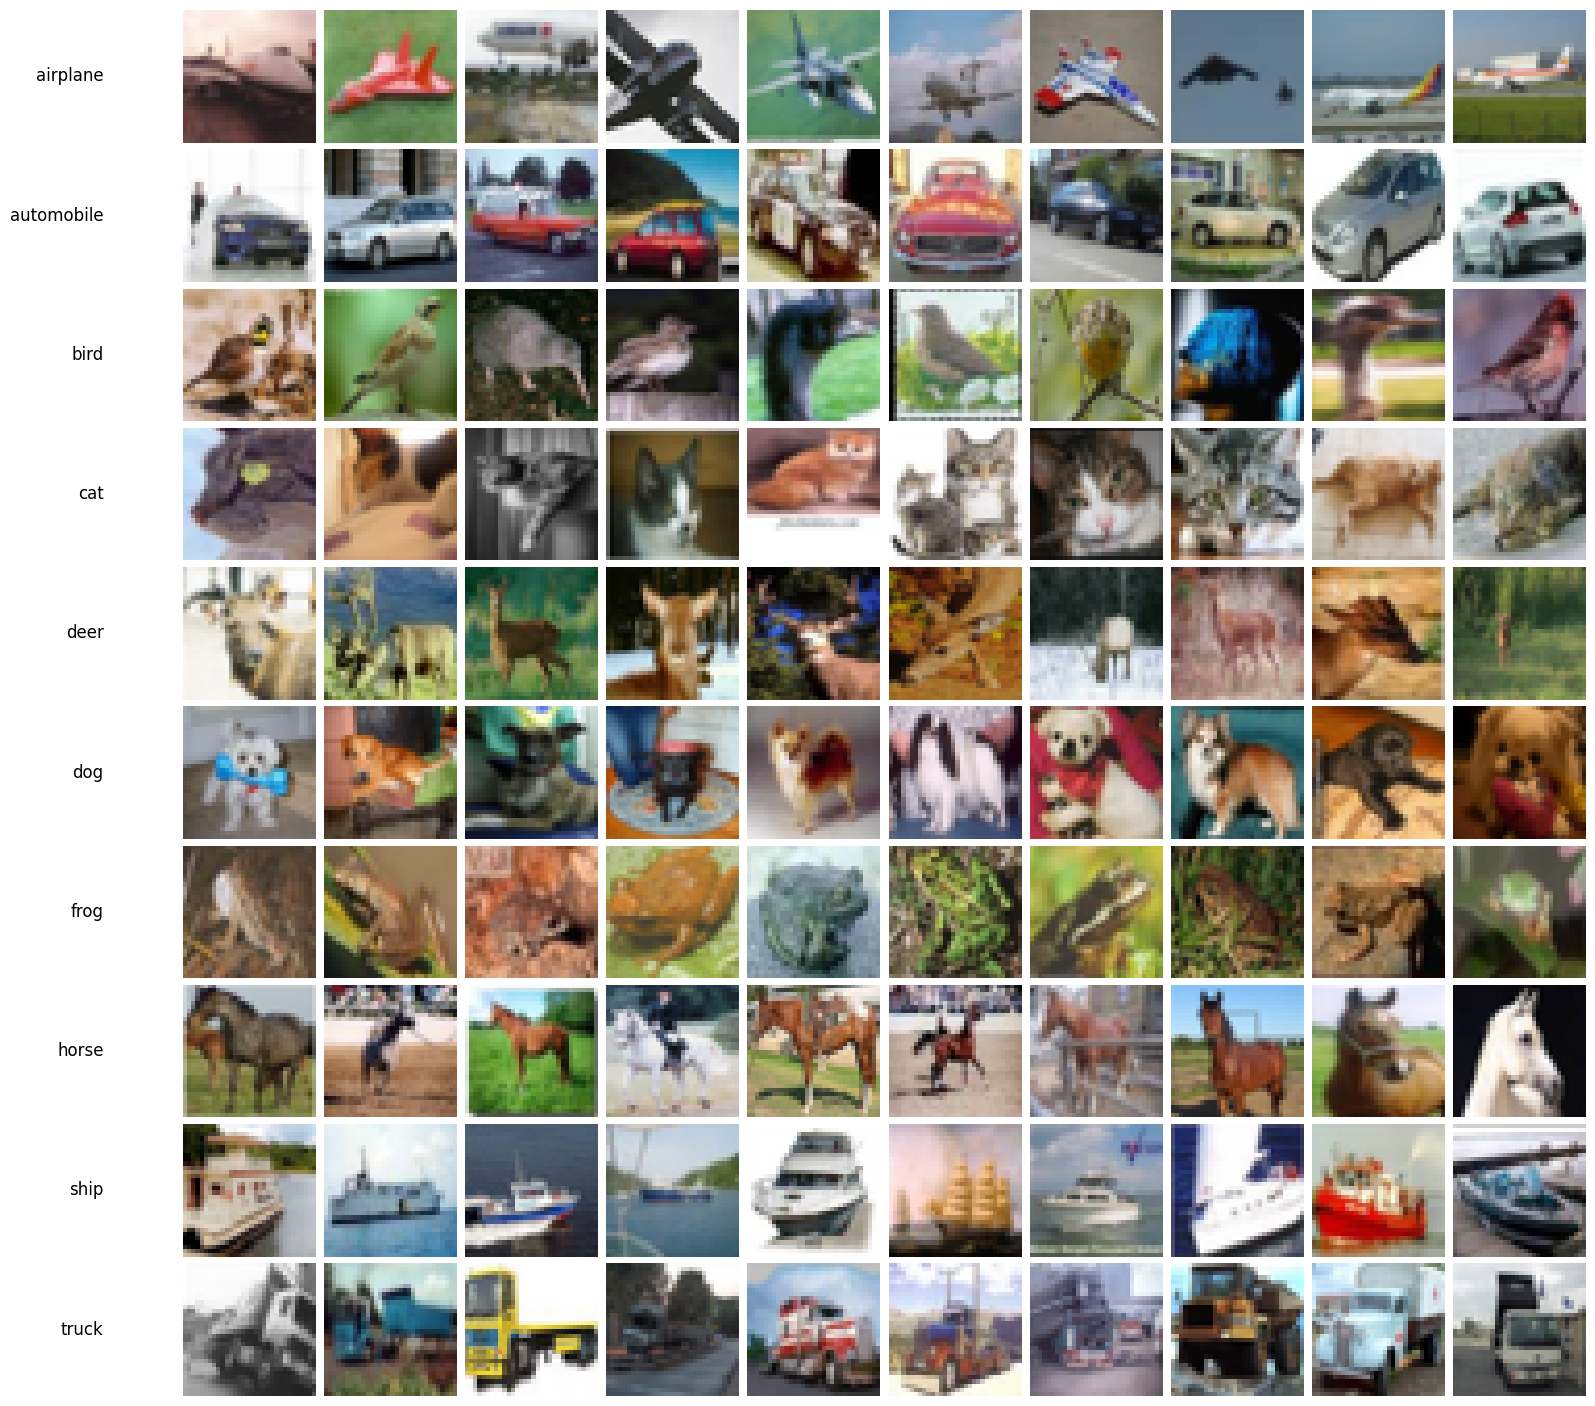

In [3]:
# class names
class_names = train_data.classes

# store all indices for each class
class_to_indices = {i: [] for i in range(len(class_names))}

# group dataset indices by class
for idx in range(len(train_data)):
    _, label = train_data[idx]
    class_to_indices[label].append(idx)

# make subplot grid
fig, axes = plt.subplots(len(class_names), 10, figsize=(18, 18))

for class_idx in range(len(class_names)):
    random_indices = np.random.choice(class_to_indices[class_idx], 10, replace=False)

    for j, idx in enumerate(random_indices):
        image, label = train_data[idx]

        # convert tensor from [C, H, W] to [H, W, C]
        image = image.permute(1, 2, 0)

        ax = axes[class_idx, j]
        ax.imshow(image, interpolation="nearest")
        ax.axis("off")

    # Class name
    axes[class_idx, 0].text(
        -0.6, 0.5, class_names[class_idx],
        transform=axes[class_idx, 0].transAxes,
        fontsize=12,
        va="center",
        ha="right"
    )

plt.subplots_adjust(left=0.12, wspace=0.05, hspace=0.05)
plt.show()

# Part 1 -  Cat Classification

## Description

In this task, a k-Nearest Neighbour (k-NN) classifier was implemented to perform binary classification on the CIFAR-10 dataset. The problem was simplified to distinguish between **cat** and **not-cat** images.

The CIFAR-10 dataset consists of 60,000 colour images of size 32×32 across 10 classes. For this task:
- The training set (50,000 images) was used to train the model
- The test set (10,000 images) was used for evaluation
- Labels were converted into binary form:
  - Cat = 1
  - Not-cat = 0


## Method
In k-NN, both the training and test images are converted into numerical vectors. The difference between a test image and each training image is measured using a distance function. The closest images are then found, and the test image is assigned the most common label among them.

An optimised implementation of k-NN from `scikit-learn` was used instead of a manual implementation, as it is more efficient for large datasets like CIFAR-10. The method from the tutorial was attempted but took way to long evne with only a subset of the training data.

Each image was:
- Converted to a tensor
- Flattened into a 3072-dimensional vector (32 × 32 × 3)

The classifier was trained using:
- Distance metric: Euclidean distance (L2) and on L1
- k value: Multiple values of K

The L1 (Manhattan) distance is defined as:
$$d_{L1}(I_1, I_2) = \sum_i |I_{1,i} - I_{2,i}|$$
The L2 (Euclidean) distance is defined as:
$$d_{L2}(I_1, I_2) = \sqrt{\sum_i (I_{1,i} - I_{2,i})^2}$$


In [4]:
def dataset_to_numpy(dataset):
    X = []
    y = []

    for img, label in dataset:
        # flatten each image into a 3072-long vector
        X.append(img.numpy().reshape(-1))
        y.append(label)

    return np.array(X), np.array(y)


def load_images_from_folder(folder_path, transform):
    image_extensions = (".jpg", ".jpeg", ".png")
    image_files = [
        filename
        for filename in os.listdir(folder_path)
        if filename.lower().endswith(image_extensions)
    ]

    X = []
    filenames = []

    for filename in image_files:
        full_path = os.path.join(folder_path, filename)
        with Image.open(full_path) as img:
            img = img.convert("RGB")
            # resize external images to CIFAR-10 size, then flatten
            X.append(transform(img).numpy().reshape(-1))
            filenames.append(filename)

    if not X:
        return np.empty((0, 3072)), []

    return np.array(X), filenames


In [5]:
def evaluate_cat_folder(knn, folder_path, X_train, y_train_raw, class_names, top_k=2):
    external_image_transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
    ])

    X_cat_folder, cat_filenames = load_images_from_folder(folder_path, external_image_transform)

    if len(X_cat_folder) == 0:
        print("No images found in cat folder.")
        return 0.0

    y_cat_pred = knn.predict(X_cat_folder)
    cat_folder_accuracy = accuracy_score(np.ones_like(y_cat_pred), y_cat_pred)

    print("Accuracy on cat images:", f"{cat_folder_accuracy * 100:.2f}%")

    # Get nearest training sample for each external cat image.
    distances, neighbor_indices = knn.kneighbors(X_cat_folder, n_neighbors=1, return_distance=True)
    distances = distances.ravel()
    neighbor_indices = neighbor_indices.ravel()

    # Show the strongest matches (smallest distance).
    best_count = min(top_k, len(X_cat_folder))
    best_order = np.argsort(distances)[:best_count]

    print(f"\nTop {best_count} nearest matches for external cat images:")
    for rank, ext_idx in enumerate(best_order, start=1):
        train_idx = neighbor_indices[ext_idx]
        train_class = class_names[y_train_raw[train_idx]]
        print(
            f"  {rank}. {cat_filenames[ext_idx]} -> train idx {train_idx} "
            f"({train_class}), distance={distances[ext_idx]:.4f}"
        )

    fig, axes = plt.subplots(best_count, 2, figsize=(8, 4 * best_count))
    if best_count == 1:
        axes = np.array([axes])

    for row, ext_idx in enumerate(best_order):
        train_idx = neighbor_indices[ext_idx]
        ext_img = np.transpose(X_cat_folder[ext_idx].reshape(3, 32, 32), (1, 2, 0))
        match_img = np.transpose(X_train[train_idx].reshape(3, 32, 32), (1, 2, 0))

        axes[row, 0].imshow(np.clip(ext_img, 0, 1))
        axes[row, 0].set_title(f"External: {cat_filenames[ext_idx]}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(np.clip(match_img, 0, 1))
        axes[row, 1].set_title(
            f"Nearest train match\nclass={class_names[y_train_raw[train_idx]]}, d={distances[ext_idx]:.4f}"
        )
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.savefig("cat_best_matches.png", dpi=150, bbox_inches="tight")
    print("Saved side-by-side matches to cat_best_matches.png")
    plt.show()

In [6]:
X_train, y_train_raw = dataset_to_numpy(train_data)
X_test, y_test_raw = dataset_to_numpy(test_data)

# binary labels: cat = 1, not cat = 0
cat_class = 3
y_train = (y_train_raw == cat_class).astype(int)
y_test = (y_test_raw == cat_class).astype(int)

subset_size = 50000  # use all training samples
X_train = X_train[:subset_size]
y_train = y_train[:subset_size]

# k-NN classifier using Euclidean distance
knn = KNeighborsClassifier(
    n_neighbors=1,
    metric="euclidean"
)

# train classifier
knn.fit(X_train, y_train)

# predict on CIFAR-10 test set
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# accuracy on cat test images only
cat_idx = np.where(y_test == 1)[0]
cat_accuracy = accuracy_score(y_test[cat_idx], y_pred[cat_idx])

print("Part 1 - KNN cat classification")
print("Training samples used:", len(X_train))
print("Overall test accuracy:", f"{accuracy * 100:.2f}%")
print("Accuracy on cat test images:", f"{cat_accuracy * 100:.2f}%")

Part 1 - KNN cat classification
Training samples used: 50000
Overall test accuracy: 86.57%
Accuracy on cat test images: 24.00%


Accuracy on cat images: 0.00%

Top 2 nearest matches for external cat images:
  1. download.jpg -> train idx 2605 (frog), distance=7.1979
  2. WP-Blog-Image-2022-35.jpg -> train idx 11186 (dog), distance=11.3410
Saved side-by-side matches to cat_best_matches.png


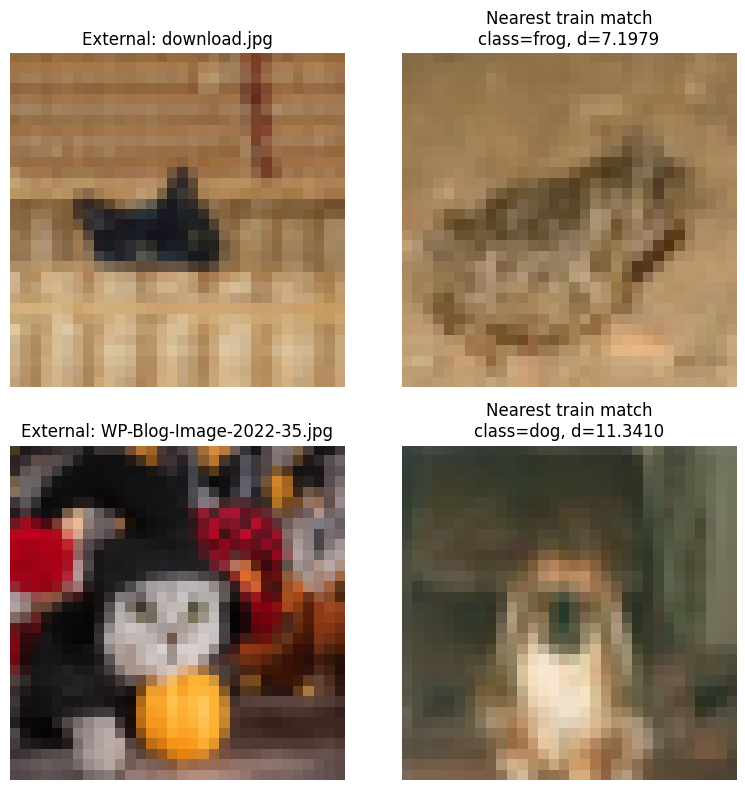

In [7]:
evaluate_cat_folder(
    knn,
    folder_path="cat",
    X_train=X_train,
    y_train_raw=y_train_raw,
    class_names=class_names,
    top_k=2,
)

## Results

Example output from the classifier:

- Training samples used: 50,000  
- Overall test accuracy: 86.57 % 
- Accuracy on cat test images: 24 %  
- Accuracy on the provided cat images: 0.0 

Predictions:
- `download.jpg` → not cat  
- `WP-Blog-Image-2022-35.jpg` → not cat  

From the above image it the result does make sense:
The 1st cat image
- is quite close to the predicted image in terms of colour
- and has a darker colour in the middle

The 2nd cat image
- both have a darker background alothoght the cat images has abit more colour its still dark
- and the middle its quite light, the face and the pumpkin, which is similar to the bogs shape.

## Discussion

The classifier achieved an overall test accuracy of 86.57%, but its accuracy on cat test images was much lower at 24%. This shows that although the classifier performs reasonably well overall, it is much less effective at identifying the cat class specifically.

This happens because the binary version of the dataset is imbalanced:
- 1000 images are cats
- 9000 images are not cats

As a result, the classifier is biased towards predicting the majority class (not cat), which increases the overall accuracy but reduces performance on cat images.

Both **L1 distance** and **L2 (Euclidean) distance** were tested. Euclidean distance gave better results, so it was selected for the final classifier. After choosing the distance metric, different values of `k` were also tested to observe how the classifier performance changed.

When tested on the provided external cat images, the classifier predicted both as not cat, giving an accuracy of 0.0. This is likely because those images differ from CIFAR-10 in several ways:
- the backgrounds are more complex
- the cat is not always fully visible
- the images contain more distracting objects
- the lighting, scale, and resolution differ from the CIFAR-10 training images

These factors make the external images harder to match correctly using a nearest neighbour classifier based only on raw pixel values.

After attempting a couple of trials, it was observed that increasing `k` increases the overall accuracy on the CIFAR-10 test data. However, performance on cat images becomes worse as `k` increases. This is likely because the provided cat images have more complex backgrounds, do not always show the full cat clearly, and include other distracting objects. There are also differences in resolution, lighting, background complexity, and object scale compared to CIFAR-10 images. As a result, the classifier finds them harder to match correctly compared to the simpler CIFAR-10 images.

### Effect of changing k

- `k = 1` → overall = `0.8657 `, cat = `0.24`
- `k = 3` → overall = `0.8871`, cat = `0.129`
- `k = 5` → overall = `0.8964`, cat = `0.085`
- `k = 7` → overall = `0.898`, cat = `0.054`

## Challenges
Changes in lighting conditions significantly alter pixel values. A brightly lit outdoor image and a dim indoor image of the same cat can appear very different in pixel space, even though they represent the same class. This makes illumination variation a key challenge for pixel-based classifiers like k-NN.
Backgrounds in real-world images also differ significantly from those in CIFAR-10. For example, a cat in a complex indoor environment with props and costumes (as seen in image 2) may not resemble the simpler, cleaner backgrounds present in the training data.
Real images may also contain different angles, zoom levels, or partial views of the object. Since CIFAR-10 images are small (32×32), resizing larger external images can distort features and lose important detail.
Intraclass variation is another significant challenge. Cats can appear very different in terms of colour, pose, and size, meaning two cat images may be far apart in pixel space despite belonging to the same class. This makes it difficult for k-NN to find meaningful nearest neighbours.
In conclusion, k-NN compares images purely based on raw pixel values, and pixel similarity does not always correspond to semantic similarity. As a result, external cat images are often matched to visually similar but semantically different training images, leading to misclassification.

## Possible Solutions
Several improvements could address these challenges. Feature extraction methods such as edge detectors or texture descriptors could capture more meaningful structural information rather than relying on raw pixel values. Normalisation and preprocessing techniques such as histogram equalisation could improve robustness to lighting and contrast variation. Using higher resolution images would preserve more detail when resizing, reducing distortion. More advanced models such as Softmax classifiers or neural networks can also learn richer representations, moving beyond simple pixel-level comparisons.

# Part 2 Softmax Classification

## Method Overview

For this task, a Softmax classifier (multinomial logistic regression) was implemented for 10-class classification on the CIFAR-10 dataset.

Two approaches were used:
1. Using the full RGB image as input (raw pixels)
2. Using extracted image features (LBP / SIFT)

This allows comparison between raw data and feature-based representations.

A Softmax classifier is used for multi-class classification problems. It takes an input feature vector and produces a probability distribution over all possible classes.

First, the input image is converted into a feature vector (either raw pixel values or extracted features). A linear transformation is applied to compute a set of scores, known as logits, for each class. These logits are then passed through the Softmax function, which converts them into probabilities that sum to 1.

Pixel values were normalised to the range [0,1] to improve numerical stability during training.

The model is trained using cross-entropy loss, which measures how different the predicted probabilities are from the true labels. During training, the weights are updated using gradient descent to minimise this loss.

As a linear classifier, Softmax can only learn linear decision boundaries, limiting its ability to model complex image patterns.

The final predicted class is the one with the highest probability.

## Use of Full RGB Image

In the first approach, the entire RGB image (32×32×3) was used as input by flattening it into a 3072-dimensional vector.

This was done because:
- It preserves all available information, including colour, intensity, and spatial variation
- It provides a direct baseline for comparison
- It allows the Softmax classifier to learn patterns directly from raw pixel values

However, using raw pixels can be computationally expensive and may include redundant or irrelevant information such as background noise. Additionally, this representation does not explicitly capture important visual features such as edges, textures, or object structure.

In [8]:
# reload 10-class labels (flattened raw pixels in [0,1])
X_train, y_train = dataset_to_numpy(train_data)
X_test, y_test = dataset_to_numpy(test_data)

class SoftmaxClassifier:
    def __init__(self, learning_rate, num_classes, num_features):
        self.learning_rate = learning_rate
        # linear layer maps input features to 10 class scores
        self.model = nn.Linear(num_features, num_classes)

        # cross entropy applies softmax internally during training
        self.criterion = nn.CrossEntropyLoss()

        # SGD updates the weights using gradients
        self.optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate)
        
    def train(self, X, y, epochs, print_every):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)

        for epoch in range(epochs):
            # Forward pass: logits (no softmax here)
            logits = self.model(X_tensor)
            loss = self.criterion(logits, y_tensor)

            # Backward pass + gradient step
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            if epoch % print_every == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:3d} - Loss: {loss.item():.4f}")

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            preds = torch.argmax(logits, dim=1)
        return preds.numpy()

# Initialize and train classifier
classifier = SoftmaxClassifier(learning_rate=0.01, num_classes=10, num_features=3072)
classifier.train(X_train, y_train, epochs=900, print_every=90)

# Predict on test set
predictions = classifier.predict(X_test)
accuracy = np.mean(predictions == y_test)

print("Part 2(a) - Softmax (raw pixels)")
print(f"Test accuracy: {accuracy * 100:.2f}%")

Epoch   0 - Loss: 2.3221
Epoch  90 - Loss: 2.0231
Epoch 180 - Loss: 1.9469
Epoch 270 - Loss: 1.9065
Epoch 360 - Loss: 1.8804
Epoch 450 - Loss: 1.8619
Epoch 540 - Loss: 1.8477
Epoch 630 - Loss: 1.8364
Epoch 720 - Loss: 1.8271
Epoch 810 - Loss: 1.8191
Epoch 899 - Loss: 1.8123
Part 2(a) - Softmax (raw pixels)
Test accuracy: 37.71%


The learning rate had a significant impact on training stability. A high learning rate (0.1) resulted in unstable training, with the loss increasing and fluctuating. Reducing the learning rate to 0.001 stabilised training but slowed convergence. A learning rate of 0.01 provided a good balance, allowing the loss to decrease smoothly and improving the test accuracy to 37.7%.

This demonstrates the importance of selecting an appropriate learning rate for gradient-based optimisation.

## Feature-Based Representation

To improve efficiency and potentially capture more meaningful information, feature-based representations were explored.

### LBP (Local Binary Pattern)
LBP is a texture descriptor that represents local patterns by comparing each pixel with its neighbouring pixels. It is:
- simple and fast to compute
- suitable for small images
- effective at capturing local texture information

However, LBP does not capture colour information and may lose some spatial structure.

### SIFT (Scale-Invariant Feature Transform)
SIFT detects keypoints in an image and describes local gradient patterns around those points. It is:
- robust to scale and rotation
- effective at capturing distinctive local features

However, SIFT is more complex and works better on larger images. Since CIFAR-10 images are very small (32×32), it may struggle to detect stable keypoints and produce reliable descriptors.

### What are P and R in LBP?

- P is the number of neighbour points around each pixel.
- R is the radius (distance from the center pixel to those neighbours).

How to read them:

- Small P and small R (for example P=8, R=1): captures fine, local texture.
- Larger P and R (for example P=16, R=2 or P=24, R=3): captures broader texture but can smooth out details on tiny 32x32 images.

Why P=8, R=1 often works on CIFAR-10:

- CIFAR-10 images are very small, so local detail is important.
- Larger radius settings can be too coarse for these small images.

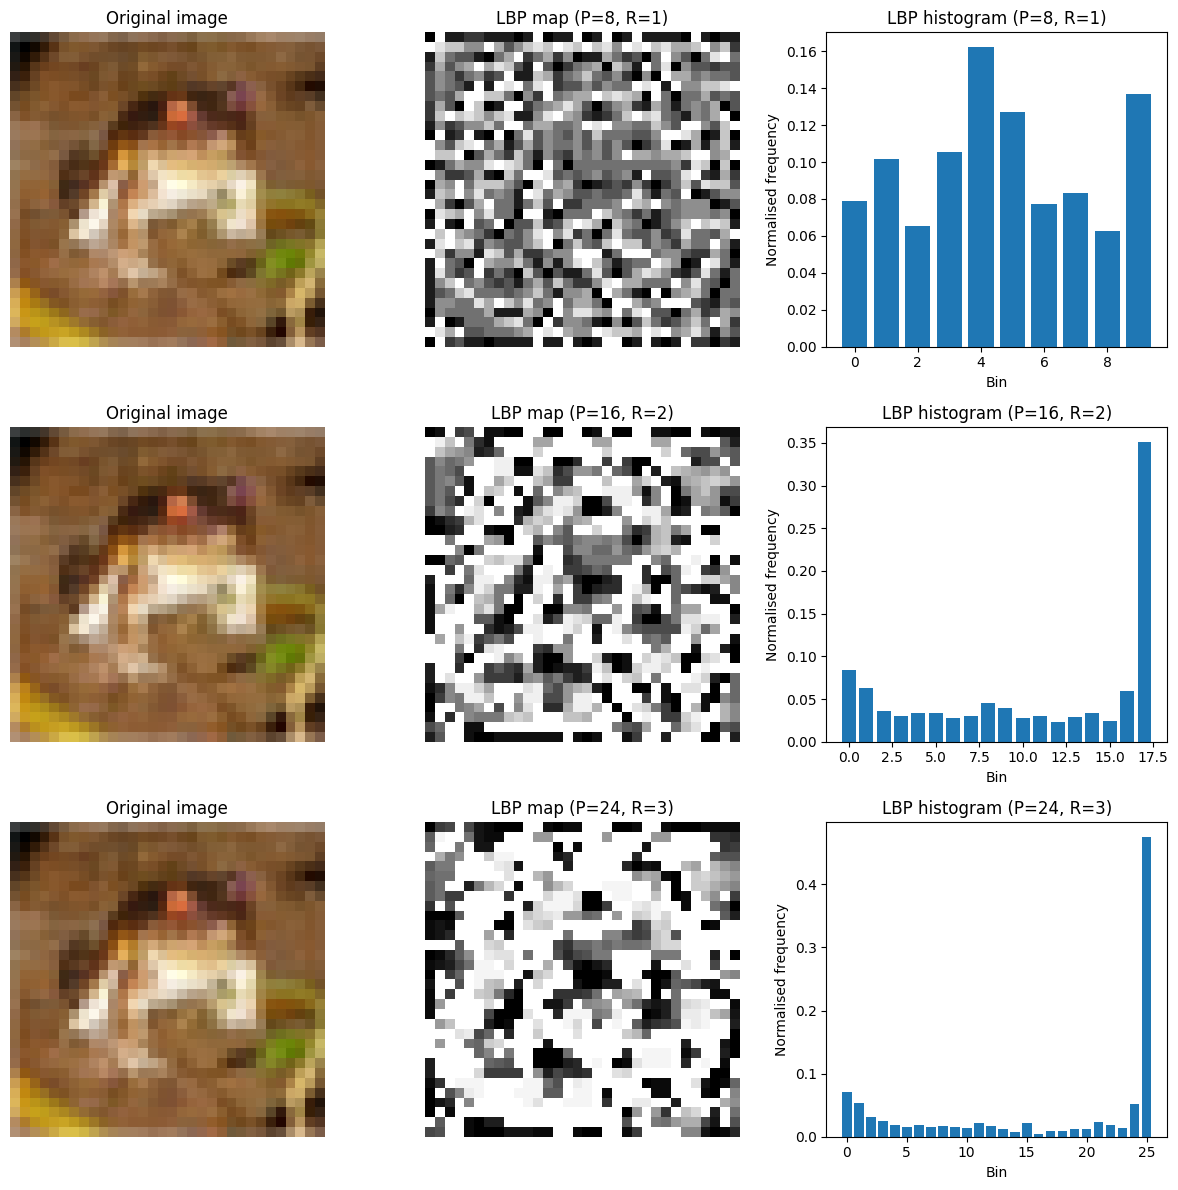

In [9]:
# Visualise the effect of P and R on one example image
def dataset_to_numpy_images(dataset):
    X = []
    y = []

    for img, label in dataset:
        # convert tensor [C, H, W] to numpy [H, W, C]
        X.append(img.numpy().transpose(1, 2, 0))
        y.append(label)

    return np.array(X), np.array(y)

X_train_img, y_train = dataset_to_numpy_images(train_data)
X_test_img, y_test = dataset_to_numpy_images(test_data)

sample_idx = 0
img_rgb = X_train_img[sample_idx]
gray = rgb2gray(img_rgb)

settings = [(8, 1), (16, 2), (24, 3)]
fig, axes = plt.subplots(len(settings), 3, figsize=(12, 4 * len(settings)))

for i, (P, R) in enumerate(settings):
    lbp = local_binary_pattern((gray * 255).astype(np.uint8), P=P, R=R, method="uniform")
    n_bins = P + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-8)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title("Original image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(lbp, cmap="gray")
    axes[i, 1].set_title(f"LBP map (P={P}, R={R})")
    axes[i, 1].axis("off")

    axes[i, 2].bar(np.arange(n_bins), hist)
    axes[i, 2].set_title(f"LBP histogram (P={P}, R={R})")
    axes[i, 2].set_xlabel("Bin")
    axes[i, 2].set_ylabel("Normalised frequency")

plt.tight_layout()
plt.show()

## Expected Behaviour

It was expected that:
- Using raw RGB pixels would give reasonable performance due to the full availability of image information
- Feature-based methods LBP might improve efficiency and robustness by focusing on important visual characteristics

However, it was also expected that:
- LBP would perform reasonably well due to its suitability for small images
- SIFT might perform poorly due to the small size and limited detail of CIFAR-10 images

In [10]:
X_train_img, y_train = dataset_to_numpy_images(train_data)
X_test_img, y_test = dataset_to_numpy_images(test_data)

def extract_lbp_features(X, P=8, R=1):
    features = []

    for img in X:
        # convert RGB image to grayscale
        gray = rgb2gray(img)
        gray = (gray * 255).astype(np.uint8)
        
        # compute LBP image
        lbp = local_binary_pattern(gray, P=P, R=R, method="uniform")

        # histogram of LBP values
        n_bins = P + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))

        # normalise histogram
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-8)

        features.append(hist)

    return np.array(features)

X_train_feat = extract_lbp_features(X_train_img)
X_test_feat = extract_lbp_features(X_test_img)

# initialise and train classifier on LBP features
classifier = SoftmaxClassifier(
    learning_rate=10,
    num_classes=10,
    num_features=X_train_feat.shape[1]
)
classifier.train(X_train_feat, y_train, epochs=1800, print_every=360)

# predict on test set
predictions = classifier.predict(X_test_feat)
accuracy = np.mean(predictions == y_test)

print("Part 2(b) - Softmax (LBP features)")
print(f"Test accuracy: {accuracy * 100:.2f}%")

Epoch   0 - Loss: 2.3241
Epoch 360 - Loss: 2.1555
Epoch 720 - Loss: 2.1128
Epoch 1080 - Loss: 2.0908
Epoch 1440 - Loss: 2.0767
Epoch 1799 - Loss: 2.0668
Part 2(b) - Softmax (LBP features)
Test accuracy: 27.66%


## Feature Choice Justification

Both **LBP** and **SIFT** were tested as feature representations for the Softmax classifier.

SIFT was not chosen for two reasons. First, SIFT constructs descriptors based on gradient 
orientations which are relatively high dimensional compared to LBP, making it less 
practical for large datasets like CIFAR-10. Second, CIFAR-10 images are very small 
(32×32), meaning there is insufficient resolution for reliable keypoint detection, so the 
extracted descriptors were not as useful for classification.

LBP was therefore chosen as the final feature representation because it is simple, 
efficient, and well-suited for small images such as CIFAR-10. It captures local texture 
patterns by comparing each pixel with its neighbours, producing a compact histogram 
feature representation. This is significantly lower dimensional than the original 
3072-dimensional pixel vector, reducing computational cost and training time.

The raw-pixel Softmax classifier achieved a test accuracy of 37.96% on the 10-class 
CIFAR-10 task. The LBP-based Softmax classifier achieved a lower test accuracy of 
27.55%. This is because LBP removes colour information and does not preserve spatial 
structure — both of which are important for distinguishing CIFAR-10 classes. Many 
classes that rely heavily on colour or global shape become difficult to separate using 
texture alone.

## Challenges

The original image classifier required significant computation time due to the large input 
size (3072 features per image). Additionally, as a linear model, Softmax can only learn 
linear decision boundaries, limiting its ability to capture complex relationships between 
features and class labels.

For the LBP-based classifier, the main challenge was information loss during feature 
extraction. Converting images to grayscale removes colour information, and using a 
histogram removes spatial structure both of which are important for distinguishing 
CIFAR-10 classes. This explains why LBP achieved lower accuracy (27.55%) compared 
to raw pixels (37.96%), despite being faster to compute. Many CIFAR-10 classes that 
rely heavily on colour or global shape become difficult to separate using texture alone.

# Part 3 Neural Network Classification 


## Method
A feedforward neural network with one hidden layer was implemented for 10-class classification on the CIFAR-10 dataset. The input consists of flattened 32×32×3 images (3072 features), which are passed through a hidden layer with ReLU activation, followed by an output layer producing 10 class scores.

The model was trained using cross-entropy loss and optimised using the Adam optimiser.

In [11]:
# simple neural network with one hidden layer
class NeuralNetwork(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()

        # input -> hidden -> output
        self.fc1 = nn.Linear(3072, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten image
        x = self.relu(self.fc1(x))
        return self.fc2(x)


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [12]:
train_data, val_data = random_split(train_data, [45000, 5000])


# optuna objective
def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 128, 512, step=128)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=128)

    model = NeuralNetwork(hidden_size)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # short training for tuning
    for _ in range(5):
        model.train()
        for images, labels in train_loader:
            loss = criterion(model(images), labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return evaluate(model, val_loader)


# run optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("Best params:", study.best_params)

[I 2026-04-27 12:21:54,718] A new study created in memory with name: no-name-fbf52ab5-0920-4f0e-8066-24a58ff0885e
[I 2026-04-27 12:22:56,744] Trial 0 finished with value: 0.3774 and parameters: {'hidden_size': 128, 'lr': 0.0014891909930314713}. Best is trial 0 with value: 0.3774.
[I 2026-04-27 12:24:13,954] Trial 1 finished with value: 0.4396 and parameters: {'hidden_size': 384, 'lr': 0.003859246393878351}. Best is trial 1 with value: 0.4396.
[I 2026-04-27 12:25:25,246] Trial 2 finished with value: 0.387 and parameters: {'hidden_size': 384, 'lr': 0.003949805060637942}. Best is trial 1 with value: 0.4396.
[I 2026-04-27 12:27:37,848] Trial 3 finished with value: 0.3402 and parameters: {'hidden_size': 512, 'lr': 0.007605067977586109}. Best is trial 1 with value: 0.4396.
[I 2026-04-27 12:30:20,353] Trial 4 finished with value: 0.4432 and parameters: {'hidden_size': 384, 'lr': 0.0002565355307404496}. Best is trial 4 with value: 0.4432.


Best params: {'hidden_size': 384, 'lr': 0.0002565355307404496}


In [13]:
# final model
model = NeuralNetwork(study.best_params["hidden_size"])
optimizer = optim.Adam(model.parameters(), lr=study.best_params["lr"])
criterion = nn.CrossEntropyLoss()

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

# full training
for epoch in range(10):
    model.train()
    for images, labels in train_loader:
        loss = criterion(model(images), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Test Acc: {evaluate(model, test_loader)*100:.2f}%")

print("Final Test Accuracy:", evaluate(model, test_loader)*100)

Epoch 1, Test Acc: 36.80%
Epoch 2, Test Acc: 39.68%
Epoch 3, Test Acc: 41.98%
Epoch 4, Test Acc: 42.57%
Epoch 5, Test Acc: 45.02%
Epoch 6, Test Acc: 45.55%
Epoch 7, Test Acc: 45.00%
Epoch 8, Test Acc: 45.92%
Epoch 9, Test Acc: 46.37%
Epoch 10, Test Acc: 47.40%
Final Test Accuracy: 47.4


## Optuna
Optuna was used to optimise the hyperparameters of the neural network. The best configuration found was:

- Hidden layer size: 384
- Learning rate: 0.00145

This configuration achieved the highest validation accuracy during tuning (44.78%). Using 
these parameters, the final model was trained and achieved a test accuracy of 46.84%.

The use of Optuna enabled efficient exploration of the hyperparameter space and improved 
model performance compared to manual tuning.

## Design
A feedforward neural network with one hidden layer was implemented for CIFAR-10 classification. The input layer consists of 3072 features (flattened image), followed by a hidden layer with 384 neurons and ReLU activation, and an output layer with 10 neurons.

The hidden layer introduces non-linearity, allowing the model to learn more complex decision boundaries than a linear Softmax classifier. ReLU was chosen due to its simplicity and effectiveness in deep learning models.

The Adam optimiser was used because it adapts the learning rate during training and provides faster convergence. Cross-entropy loss was used as it is standard for multi-class classification.

## Challenges and Possible Solutions

A major challenge is the high dimensionality of the input. Each CIFAR-10 image is 
represented by 3072 features corresponding to the flattened 32×32×3 RGB image. 
Many of these features may be redundant or irrelevant, increasing computational cost 
and making it harder for the model to learn meaningful patterns.

Another challenge is training instability due to noisy gradient updates. When gradients 
are computed over very small subsets of data, they can vary significantly between 
iterations, leading to slow or unstable convergence. This was addressed using batched 
training, where gradients are averaged over a batch of samples rather than individual 
images. Using an appropriate batch size improves stability and leads to more consistent 
updates. However, very large batch sizes increase computation time and memory usage, 
so Optuna was used to tune this parameter alongside hidden layer size and learning rate.

The network contains only a single hidden layer, which limits its capacity to learn 
complex patterns. If the model is too simple relative to the problem it may underfit, 
failing to capture the underlying structure of the data and performing poorly on both 
training and test sets. Conversely, increasing capacity too much may lead to overfitting, 
where the model learns patterns too specific to the training data and fails to generalise 
to unseen images. The number of layers and neurons must therefore be considered 
carefully to balance these two effects.

A possible solution is to use convolutional neural networks (CNNs). Unlike fully 
connected networks which flatten the image and treat each pixel independently, CNNs 
preserve spatial structure by applying small filters across the image to detect local 
features such as edges and textures. These features are then combined across layers to 
form higher level representations, making CNNs significantly more effective for image 
classification tasks.

## Result and Comparison

The neural network achieved a final test accuracy of 46.84% on the CIFAR-10 test set.

Compared to the Softmax classifier using raw pixels (37.96%), the neural network 
improved performance by introducing a hidden layer with ReLU activation. This allows 
the model to learn non-linear decision boundaries, capturing more complex relationships 
between input features and class labels than a linear classifier can.

Compared to the LBP-based Softmax classifier (27.55%), the neural network 
significantly outperformed, indicating that raw pixel inputs combined with learned 
representations are more effective than handcrafted texture features for CIFAR-10.

Although k-NN achieved a high overall accuracy (86.57%), this is largely due to the 
class imbalance in the binary classification setup and its reliance on storing and 
comparing all training samples at inference time. The neural network instead learns a 
parametric model, making it more scalable and better suited to real-world applications. 
It also demonstrates better generalisation through its learned feature representations, 
whereas k-NN is sensitive to noise and high dimensional data as discussed in Part 1.

# Acknowledgement of AI Use

I acknowledge the use of ChatGPT (OpenAI, https://chat.openai.com/) to support the completion of this assessment. ChatGPT was used to help clarify technical concepts, improve the structure and wording of the report, and assist in understanding and implementing algorithms such as k-NN, Softmax classification, and neural networks.

All code implementations, experimental results, and final explanations were developed and verified by me.